# Temporal Multiplex Directed Networks for the Semiconductor Industry

A Temporal Multiplex Directed Network $\mathcal{M}$ is defined as a sequence of layers $L = \{L_1, L_2, \dots, L_M\}$, where each layer represents a different type of interaction (Financial, Supply Chain, etc.) over time steps $t \in \{1, \dots, T\}$.

The state of the network at any time $t$ is represented by a Supra-Adjacency Tensor $\mathcal{A}$: $$\mathcal{A}_{i,j, \alpha}(t)$$
Where: 
$i, j \in \{1, \dots, N\}$ are the semiconductor companies (nodes). 
$\alpha \in \{1, \dots, M\}$ is the specific layer (e.g., $\alpha=1$ for the Financial Layer, $\alpha=2$ for the Supply Chain Layer, $\alpha=3$ for the Ownership Layer). $t$ is the temporal window (e.g., the specific week).

## Financial Layer

TODO WRITE A SUMMARY OF THE STEPS DONE AND WHAT WAS ACHIEVED


### DATA ACQUISITION

In [ ]:
import sys
sys.path.append('..')
import numpy as np
import pandas as pd
import yfinance as yf
import plotly.express as px
import matplotlib.pyplot as plt
import networkx as nx
from py_scripts.project2 import financial_layer as fl

foundries = {
    "TSM": "Taiwan Semiconductor Manufacturing Company Limited",
    "SMSN.IL": "Samsung Electronics Co., Ltd.",
    "INTC": "Intel Corporation",
    "UMC": "United Microelectronics Corporation",
    "GFS": "GlobalFoundries Inc.",
    "0981.HK": "Semiconductor Manufacturing International Corporation",
}

fabless_designers = {
    "NVDA": "NVIDIA Corporation",
    "AMD": "Advanced Micro Devices, Inc.",
    "AVGO": "Broadcom Inc.",
    "ARM": "Arm Holdings plc",
    "QCOM": "QUALCOMM Incorporated",
    "2454.TW": "MediaTek Inc.",
    "MRVL": "Marvell Technology, Inc.",
    "ALAB": "Astera Labs, Inc.",
}

memory = {
    "MU": "Micron Technology, Inc.",
    "000660.KS": "SK Hynix Inc.",
}

wfe = {
    "ASML": "ASML Holding N.V.",
    "AMAT": "Applied Materials, Inc.",
    "LRCX": "Lam Research Corporation",
    "KLAC": "KLA Corporation",
    "8035.T": "Tokyo Electron Limited",
    "6857.T": "Advantest Corporation",
    "TER": "Teradyne, Inc.",
    "6920.T": "Lasertec Corporation",
    "SNPS": "Synopsys, Inc.",
    "CDNS": "Cadence Design Systems, Inc.",
}

osat_packaging = {
    "3711.TW": "ASE Technology Holding Co., Ltd.",
    "AMKR": "Amkor Technology, Inc.",
    "042700.KS": "Hanmi Semiconductor Co., Ltd.",
}

analog_auto_power = {
    "TXN": "Texas Instruments Incorporated",
    "ADI": "Analog Devices, Inc.",
    "NXPI": "NXP Semiconductors N.V.",
    "STNE": "STMicroelectronics N.V.",
    "ON": "ON Semiconductor Corporation",
    "IFX.DE": "Infineon Technologies AG",
    "MCHP": "Microchip Technology Incorporated"
}

# Organize spheres
spheres = {
    "Foundries": foundries,
    "Fabless Designers": fabless_designers,
    "Memory": memory,
    "WFE (Equipment)": wfe,
    "OSAT & Packaging": osat_packaging,
    "Analog/Auto/Power": analog_auto_power,
}

# Download and visualize each sphere
for sphere_name, tickers_dict in spheres.items():
    data = yf.download(list(tickers_dict.keys()), start="2023-01-01", progress=False)['Close']
    
    fig = px.line(data, x=data.index, y=data.columns,
                  title=f'{sphere_name} - Close Price (Since 2023)',
                  labels={'value': 'Close Price (USD)', 'variable': 'Ticker'})
    fig.update_layout(xaxis_title='Date', yaxis_title='Price (USD)')
    fig.show()

In [10]:
# Compute and visualize returns for each sphere
total_returns = pd.DataFrame()
for sphere_name, tickers_dict in spheres.items():
    data = yf.download(list(tickers_dict.keys()), start="2023-01-01", progress=False)['Close']
    returns = np.log(data / data.shift(1)).dropna()
    total_returns = pd.concat([total_returns, returns], axis=1)

    fig = px.line(returns, x=returns.index, y=returns.columns,
                  title=f'{sphere_name} - Returns (Since 2023)',
                  labels={'value': 'Returns', 'variable': 'Ticker'})
    fig.update_layout(xaxis_title='Date', yaxis_title='Returns')
    fig.show()

C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_34488\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_34488\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_34488\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


C:\Users\Youdas Yessad\AppData\Local\Temp\ipykernel_34488\3583276182.py:6: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  total_returns = pd.concat([total_returns, returns], axis=1)


### Breaking Symmetry in the Financial Layer

To transform a standard undirected correlation into a Directed Lead-Lag Network, we define the directed adjacency matrix $A^{(dir)}$ using a time-shifted correlation.

For any two assets $i$ and $j$, the directed edge weight $E_{i \to j}$ is calculated as:$$E_{i \to j}(t) = \text{corr}(R_{i, t}, R_{j, t+1})$$
Conversely, the influence of $j$ on $i$ is:$$E_{j \to i}(t) = \text{corr}(R_{j, t}, R_{i, t+1})$$
In this construction, $A^{(dir)}$ is asymmetric ($E_{i \to j} \neq E_{j \to i}$), representing the directional flow of information from a "leader" to a "lagger."

In [13]:
window = 38*2 # T/N ratio of 2 for the Marchenko-Pastur filtering
graphs = []

total_returns_list = total_returns.dropna()
# Apply Marchenko-Pastur filtering in a weekly rolling window
for i in range(window, len(total_returns_list), 5):
    window_slice = total_returns_list.iloc[i-window : i]
    current_date = total_returns_list.index[i]
    print(window_slice)
    assym_corr_matrix = fl.assymetrical_correlation_matrix(window_slice)
    print("RETARD RETARD")
    print(assym_corr_matrix)
    clipped_corr_matrix = fl.marchenko_pastur_returns(assym_corr_matrix, window, len(window_slice))
    
    graph = nx.from_pandas_adjacency(clipped_corr_matrix, create_using=nx.DiGraph)
    graphs.append((current_date, graph))

graphs_df = pd.DataFrame(graphs, columns=['Date', 'Graph'])
graphs_df.info()
graphs_df.head()

Ticker       0981.HK       GFS      INTC   SMSN.IL       TSM       UMC  \
Date                                                                     
2024-03-22 -0.056596 -0.005158  0.003530 -0.017628  0.007786 -0.021819   
2024-03-25 -0.019170 -0.006919 -0.017536 -0.002054 -0.002208 -0.021053   
2024-03-26 -0.006473 -0.020655  0.003818  0.017664 -0.009962 -0.005019   
2024-03-27 -0.031665  0.018338  0.041517 -0.002279 -0.015607  0.003766   
2024-03-28  0.015958  0.007319  0.009097  0.008103 -0.004693  0.013690   
...              ...       ...       ...       ...       ...       ...   
2024-08-22 -0.009674 -0.039186 -0.063138 -0.015079 -0.029598 -0.027368   
2024-08-23 -0.007317  0.039403  0.021654  0.012354  0.028665  0.017192   
2024-08-28  0.000000 -0.016186 -0.023186 -0.004228 -0.007947 -0.002323   
2024-08-29  0.010916  0.014666  0.026172 -0.004246 -0.000296  0.006952   
2024-08-30  0.029711  0.014240  0.090648 -0.013567  0.014963  0.012622   

Ticker       2454.TW      ALAB       

c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\

RETARD RETARD
Ticker     0981.HK  GFS  INTC  SMSN.IL  TSM  UMC  2454.TW  ALAB  AMD  ARM  \
Ticker                                                                      
0981.HK        NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
GFS            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
INTC           NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
SMSN.IL        NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
TSM            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
UMC            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
2454.TW        NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
ALAB           NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
AMD            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
ARM            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
AVGO           NaN  NaN   NaN      NaN  NaN  NaN      NaN   Na

c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\

Ticker       0981.HK       GFS      INTC   SMSN.IL       TSM       UMC  \
Date                                                                     
2024-08-08  0.000000  0.037463  0.076024 -0.009437  0.059531  0.064539   
2024-08-09  0.048187 -0.014542 -0.038811  0.000000  0.015498 -0.004728   
2024-08-14  0.003565 -0.029407 -0.027236  0.016318 -0.013847 -0.001146   
2024-08-19  0.002356  0.014361  0.030670  0.002040  0.005200  0.021604   
2024-08-20 -0.005900 -0.014141 -0.024937 -0.002721 -0.019627 -0.013590   
...              ...       ...       ...       ...       ...       ...   
2025-01-16 -0.032790 -0.021990 -0.002539  0.002157  0.037909 -0.022294   
2025-01-17  0.091515  0.051660  0.088493 -0.002157 -0.015436  0.011209   
2025-01-22  0.004762 -0.007526  0.004126  0.008506  0.020367 -0.052778   
2025-02-04  0.081327 -0.020745 -0.004655  0.032845  0.021048  0.000000   
2025-02-05 -0.016639  0.000740  0.018490  0.007094  0.021910  0.004971   

Ticker       2454.TW      ALAB       

...

Ticker       0981.HK       GFS      INTC   SMSN.IL       TSM       UMC  \
Date                                                                     
2025-05-29  0.014599  0.004616 -0.005908  0.003984  0.005136 -0.012903   
2025-06-05  0.041069 -0.005318 -0.012923  0.030686  0.004634 -0.013210   
2025-06-10 -0.019116  0.027744  0.075223 -0.027474  0.026035  0.016614   
2025-06-11  0.004814 -0.023585 -0.065505  0.013831  0.007689  0.005057   
2025-06-12 -0.020619 -0.017005  0.004343  0.002743  0.009843  0.023677   
...              ...       ...       ...       ...       ...       ...   
2025-11-12  0.008225 -0.018557  0.000264 -0.002866 -0.001891 -0.019152   
2025-11-13  0.031578 -0.043361 -0.053671 -0.016204 -0.029400 -0.018119   
2025-11-14 -0.028171  0.010035 -0.010920 -0.009379  0.009241  0.004210   
2025-11-17 -0.007511 -0.002727 -0.023068  0.019826 -0.009915 -0.016950   
2025-11-18  0.014291 -0.003343 -0.011008 -0.042459 -0.014645  0.005682   

Ticker       2454.TW      ALAB       

c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\

RETARD RETARD
Ticker     0981.HK  GFS  INTC  SMSN.IL  TSM  UMC  2454.TW  ALAB  AMD  ARM  \
Ticker                                                                      
0981.HK        NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
GFS            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
INTC           NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
SMSN.IL        NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
TSM            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
UMC            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
2454.TW        NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
ALAB           NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
AMD            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
ARM            NaN  NaN   NaN      NaN  NaN  NaN      NaN   NaN  NaN  NaN   
AVGO           NaN  NaN   NaN      NaN  NaN  NaN      NaN   Na

c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Youdas Yessad\Documents\Coding\Network-Contagion-in-Financial-Markets\venv\Lib\site-packages\

,Date,Graph
0,2024-09-04,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."
1,2024-09-13,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."
2,2024-09-30,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."
3,2024-10-18,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."
4,2024-10-25,"(0981.HK, GFS, INTC, SMSN.IL, TSM, UMC, 2454.T..."


NetworkXError: draw_networkx_edges arg `connectionstyle` must be str or iterable

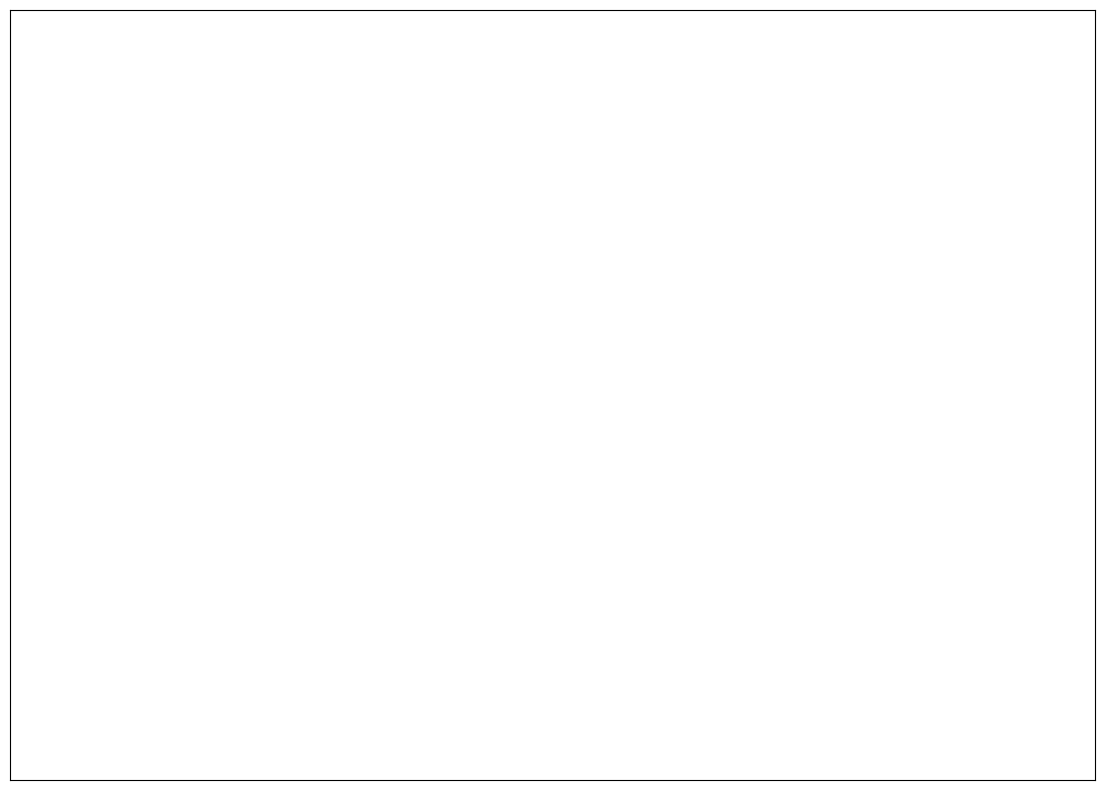

In [12]:
# Visualize the last graph for sanity check
last_date, last_graph = graphs_df.iloc[-1]

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(last_graph, k=0.5, iterations=50)
nx.draw_networkx_nodes(last_graph, pos, node_color='lightblue', node_size=500, alpha=0.9)
nx.draw_networkx_labels(last_graph, pos, font_size=9, font_weight='bold')
nx.draw_networkx_edges(last_graph, pos, edge_color='gray', arrows=True, arrowsize=15, 
                       width=0.8, connectionstyle=None, alpha=0.6)
plt.title(f'Directed Lead-Lag Network - {last_date.date()}', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

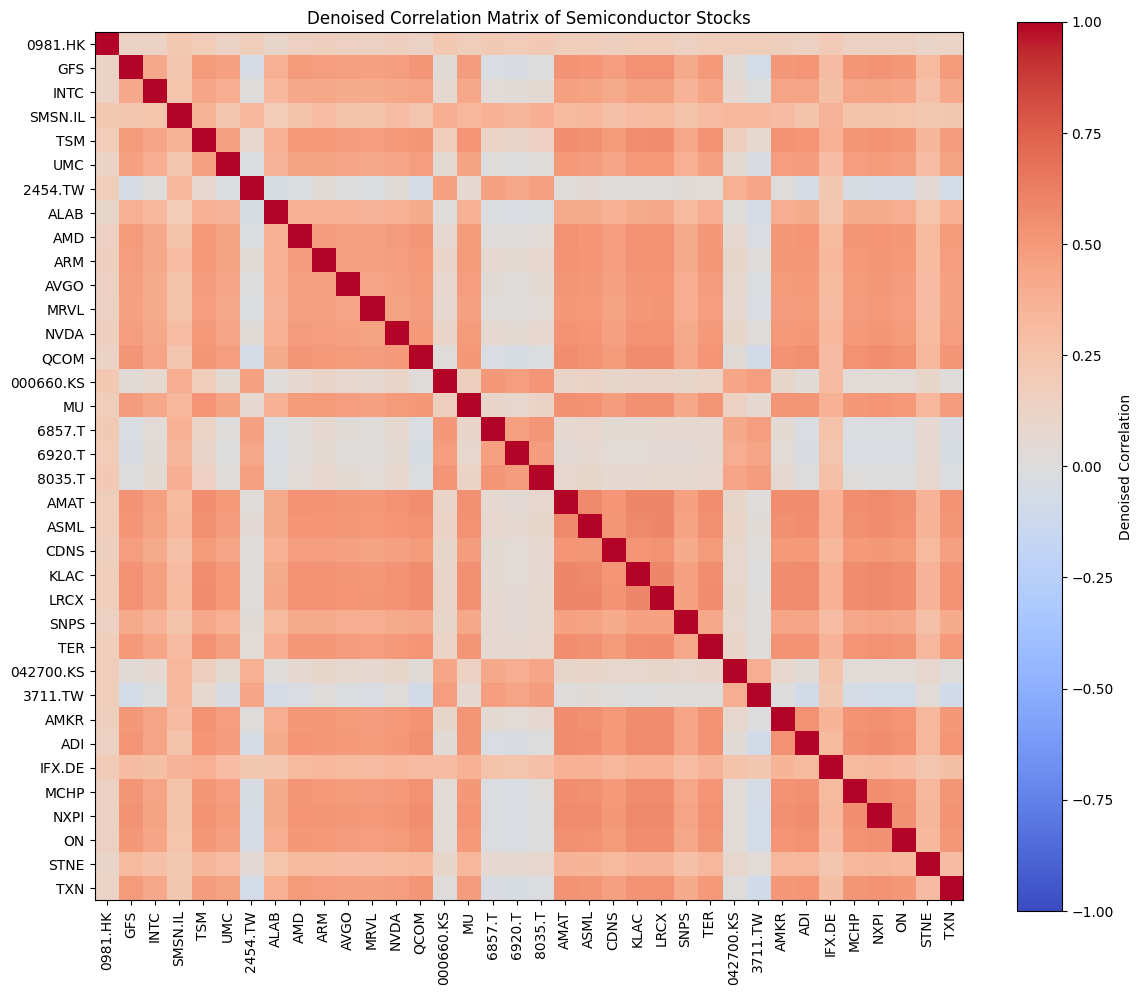

In [ ]:
#visualize the denoised correlation matrix
plt.figure(figsize=(12, 10))
plt.imshow(C_final_df, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Denoised Correlation')
plt.title('Denoised Correlation Matrix of Semiconductor Stocks')
plt.xticks(ticks=np.arange(len(C_final_df.columns)), labels=C_final_df.columns, rotation=90) 
plt.yticks(ticks=np.arange(len(C_final_df.index)), labels=C_final_df.index)
plt.tight_layout()